In [22]:
import pandas as pd
import plotly.express as px
import folium
from geopy.geocoders import Nominatim
from folium.plugins import HeatMap
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [23]:
df = pd.read_csv("./data/cleaned.csv")
df = df.drop("Unnamed: 0", axis=1)

### Number of Jobs: 597

### Number of Companies: 425

### Number of Cities: 160

# Most Common Jobs Titles


In [3]:
# Compute top 5 job titles
top_job_titles = df["clean_job_title"].value_counts().nlargest(5).index.tolist()

# Filter data to include only top 5 job titles
df_top_jobs = df[df["clean_job_title"].isin(top_job_titles)]

# Define custom color palette
colors = ["#FFA07A", "#FFC0CB", "#BA55D3", "#00BFFF", "#3CB371", "#FFD700"]

# Create bar graph
fig = px.histogram(
    df_top_jobs,
    x="clean_job_title",
    color="clean_job_title",
    color_discrete_sequence=colors,
    labels={"count": "Number of Job Postings"},
    hover_data={"clean_job_title": False},
    template="plotly_white"
)
fig.update_traces(hovertemplate="<b>Number of Job Postings:</b> %{y}")

# Update layout
fig.update_layout(
    title="Top 6 Job Titles by Number of Postings",
    xaxis_title="Job Title",
    yaxis_title="Number of Job Postings",
    xaxis={"categoryorder": "total descending", "tickmode": "array", "ticklen": 10},
    showlegend=False,
)

# Show plot
fig.show()

## Where are most jobs Located


In [4]:
# Compute top 5 job titles
df_reduce = df[df["location"] != "United States"]
top_locations = df_reduce["location"].value_counts().nlargest(10).index.tolist()

# Filter data to include only top 5 job titles
df_top_locations = df[df["location"].isin(top_locations)]

# Define custom color palette
colors = [
    "#FFA07A",
    "#FFC0CB",
    "#BA55D3",
    "#00BFFF",
    "#3CB371",
    "#FFD700",
    "#FF1493",
    "#9370DB",
    "#20B2AA",
    "#F08080",
]

# Create bar graph
fig = px.histogram(
    df_top_locations,
    x="location",
    color="location",
    color_discrete_sequence=colors,
    labels={"count": "Number of Job Postings"},
    hover_data={"location": False},
    template = "plotly_white"
)
fig.update_traces(hovertemplate="<b>Number of Job Postings:</b> %{y}")

# Update layout
fig.update_layout(
    title="Top 10 Locations by Number of Postings",
    xaxis_title="Job Title",
    yaxis_title="Number of Job Postings",
    xaxis={"categoryorder": "total descending", "tickmode": "array", "ticklen": 10},
    showlegend=False,
)

# Show plot
fig.show()

In [5]:
# Compute top 5 job titles
top_job_titles = df["clean_job_title"].value_counts().nlargest(5).index.tolist()

# Filter data to include only top 5 job titles
df_top_jobs = df[df["clean_job_title"].isin(top_job_titles)]

# Compute top 5 job posting sites
top_sites = df["via"].value_counts().nlargest(5).index.tolist()


# Filter data to include only top 5 job titles
df_top_jobs = df_top_jobs[df_top_jobs["via"].isin(top_sites)]

# Compute percentages of work from home for each job title
job_title_percents = (
    df_top_jobs.groupby(["clean_job_title", "via"])["via"]
    .count()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
)
colors = ["#FFA07A", "#FFC0CB", "#BA55D3", "#00BFFF", "#3CB371", "#FFD700"]

job_title_percents.fillna(0)
# Create stacked bar chart
fig = go.Figure(
    data=[
        go.Bar(
            name="Angel List",
            x=top_job_titles,
            y=job_title_percents["via AngelList"],
            marker_color=colors[0],
            hovertemplate="Percentage: %{y:.1f}%",
        ),
        go.Bar(
            name="Level",
            x=top_job_titles,
            y=job_title_percents["via Lever"],
            marker_color=colors[1],
            hovertemplate="<b>Percentage:</b> %{y:.1f}%",
        ),
        go.Bar(
            name="LinkedIn",
            x=top_job_titles,
            y=job_title_percents["via LinkedIn"],
            marker_color=colors[2],
            hovertemplate="<b>Percentage:</b> %{y:.1f}%",
        ),
        go.Bar(
            name="Upwork",
            x=top_job_titles,
            y=job_title_percents["via Upwork"],
            marker_color=colors[3],
            hovertemplate="<b>Percentage:</b> %{y:.1f}%",
        ),
        go.Bar(
            name="ZipRecruiter",
            x=top_job_titles,
            y=job_title_percents["via ZipRecruiter"],
            marker_color=colors[4],
            hovertemplate="<b>Percentage:</b> %{y:.1f}%",
        ),
    ]
)

# Update layout
fig.update_layout(
    title="Job Postings by Site",
    xaxis_title="Job Title",
    yaxis_title="Percent of Job Postings",
    barmode="stack",
    xaxis={"categoryorder": "max descending", "tickmode": "array", "ticklen": 10},
    legend=dict(title="Job Site"),
    template = "plotly_white"
)
fig.update_xaxes(tickangle=0)
# Show plot
fig.show()

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_33027/2741582061.py:19: FutureWarning:

Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)



In [6]:
df_reduce = df[df["location"] != "United States"]
df_reduce = df_reduce.dropna(subset=["location_coord"])

# Convert string coordinates to floats
heat_data = [eval(coord) for coord in df_reduce["location_coord"]]

# Create a Folium map centered on the US
m = folium.Map(location=[40, -95], zoom_start=4)

# Add heatmap layer
HeatMap(heat_data, radius=15).add_to(m)

# Display map
m

In [7]:
# Compute top 6 job titles
top_job_titles = df["clean_job_title"].value_counts().nlargest(5).index.tolist()

# Filter data to include only top 6 job titles
df_top_jobs = df[df["clean_job_title"].isin(top_job_titles)]

# Create a new column to represent work from home as a string for plotting
df_top_jobs["wfh_str"] = np.where(df_top_jobs["work_from_home"] == 1, "Yes", "No")

# Compute percentages of work from home for each job title
job_title_percents = (
    df_top_jobs.groupby(["clean_job_title", "wfh_str"])["work_from_home"]
    .count()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack()
)
colors = ["#BA55D3", "#00BFFF"]

# Create stacked bar chart
fig = go.Figure(
    data=[
        go.Bar(
            name="No",
            x=top_job_titles,
            y=job_title_percents["No"],
            marker_color=colors[0],
            hovertemplate="Percentage: %{y:.1f}%",
        ),
        go.Bar(
            name="Yes",
            x=top_job_titles,
            y=job_title_percents["Yes"],
            marker_color=colors[1],
            hovertemplate="<b>Percentage:</b> %{y:.1f}%",
        ),
    ]
)

# Update layout
fig.update_layout(
    title="Percentage of Work from Home Job Postings",
    xaxis_title="Job Title",
    yaxis_title="Percent of Job Postings",
    barmode="stack",
    xaxis={"categoryorder": "min ascending", "tickmode": "array", "ticklen": 10},
    legend=dict(title="Work From Home"),
)
fig.update_xaxes(tickangle=0)
# Show plot
fig.show()

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_33027/1794117047.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_33027/1794117047.py:15: FutureWarning:

Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)



In [8]:
# Convert the minimum_education column to a categorical data type
df["minimum_education"] = df["minimum_education"].astype("category")

df_reduce = df[
    (df["clean_job_title"] == "Machine Learning Engineer")
    | (df["clean_job_title"] == "Data Scientist")
    | (df["clean_job_title"] == "Data Analyst")
    | (df["clean_job_title"] == "Deep Learning Engineer")
    | (df["clean_job_title"] == "Blockchain Engineer")
]

# Group the data by job title and minimum education
grouped = (
    df_reduce.groupby(["clean_job_title", "minimum_education"])
    .size()
    .reset_index(name="counts")
)

# Define a custom color scale
colors = ["#FFA07A", "#FFC0CB", "#BA55D3", "#00BFFF", "#3CB371", "#FFD700"]

# Create the sunburst plot
fig = px.sunburst(
    grouped,
    path=["clean_job_title", "minimum_education"],
    values="counts",
    color="clean_job_title",
    color_discrete_sequence=colors,
)

# Update the hovertemplate
fig.update_traces(hovertemplate="<b>%{id} </b>" + "<br>Total Job Postings: %{value}")

# Update the layout with a title and axis labels
fig.update_layout(
    title="Minimum Education Required by Job Title",
    xaxis=dict(title="Job Title"),
    yaxis=dict(title="Minimum Education"),
    uniformtext=dict(minsize=10, mode="hide"),
    height=600,
    width=600,
)

fig.show()

## Are job postings different by city


In [9]:
location_list = [
    "Washington, DC",
    "New York, NY",
    "San Francisco, CA",
    "Arlington, VA",
    "Chicago, IL",
    "Annapolis Junction, MD",
    "Herndon, VA",
    "Seattle, WA",
    "McLean, VA",
    "Paolo Alto, CA",
]
df_reduce = df_reduce[df_reduce["location"].isin(location_list)]
# Group the data by city and job title, count the number of occurrences
grouped = (
    df_reduce.groupby(["location", "clean_job_title"])
    .size()
    .reset_index(name="# of Job Postings")
)

colors = ["#FFA07A", "#FFC0CB", "#BA55D3", "#00BFFF", "#3CB371", "lightblue"]

# Create a treemap using plotly.express
fig = px.treemap(
    grouped,
    path=[px.Constant("USA"), "location", "clean_job_title"],
    values="# of Job Postings",
    color="clean_job_title",
    color_discrete_sequence=colors,
)

# Update the hovertemplate
fig.update_traces(hovertemplate="<b>%{label} </b>" + "<br>Total Job Postings: %{value}")
# Update the layout with a title
fig.update_layout(
    title="Most Common Job Titles by City",
)

# Show the plot
fig.show()

## How are the required skills different by job


In [10]:
grouped = df[
    (df["clean_job_title"] == "Machine Learning Engineer")
    | (df["clean_job_title"] == "Data Scientist")
    | (df["clean_job_title"] == "Data Analyst")
    | (df["clean_job_title"] == "Deep Learning Engineer")
    | (df["clean_job_title"] == "Blockchain Engineer")
]
grouped = grouped.drop("work_from_home", axis=1)
grouped = grouped.groupby("clean_job_title").mean() * 100

# create a heatmap using plotly express
fig = px.imshow(
    grouped,
    title="Required Skills by Job Type",
    y=grouped.index,
    labels=dict(x="Skills", y="Job Title", color="Percentage of Jobs"),
    x=[
        "Python",
        "SQL",
        "Machine Learning",
        "Communication",
        "Software Engineering",
        "Deep Learning",
        "Language Processing",
        "Pytorch",
        "Computer Vision",
        "Tableau",
        "Management",
        "Tensorflow",
    ],
    color_continuous_scale="Blues",
)

# make the tooltip pretty
fig.update_traces(
    hovertemplate="<b>Job Title:</b> %{y}<br>"
    + "<b>Skill:</b> %{x}"
    + "<br><b>Percentage of Jobs:</b>  %{z:.2f}%<br>"
)

fig.update_layout(width=1000)
fig.show()

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_33027/149110318.py:9: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [21]:
df["Qualifications"]

0      language fluency: english (required) the requi...
1                                                    NaN
2      ability to parse and understand evm (and/or so...
3      we’re looking for a capable generalist enginee...
4                                                    NaN
                             ...                        
589                                                  NaN
590    has experience with the latest nlp techniques ...
591    3+ years’ experience or compensating advanced ...
592    these are in mix language english, hindi and t...
593    expertise in at least one key ml area consiste...
Name: Qualifications, Length: 594, dtype: object

/var/folders/m0/y_433zr10m79zw6c3ccqn31c0000gn/T/ipykernel_32798/2131167570.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



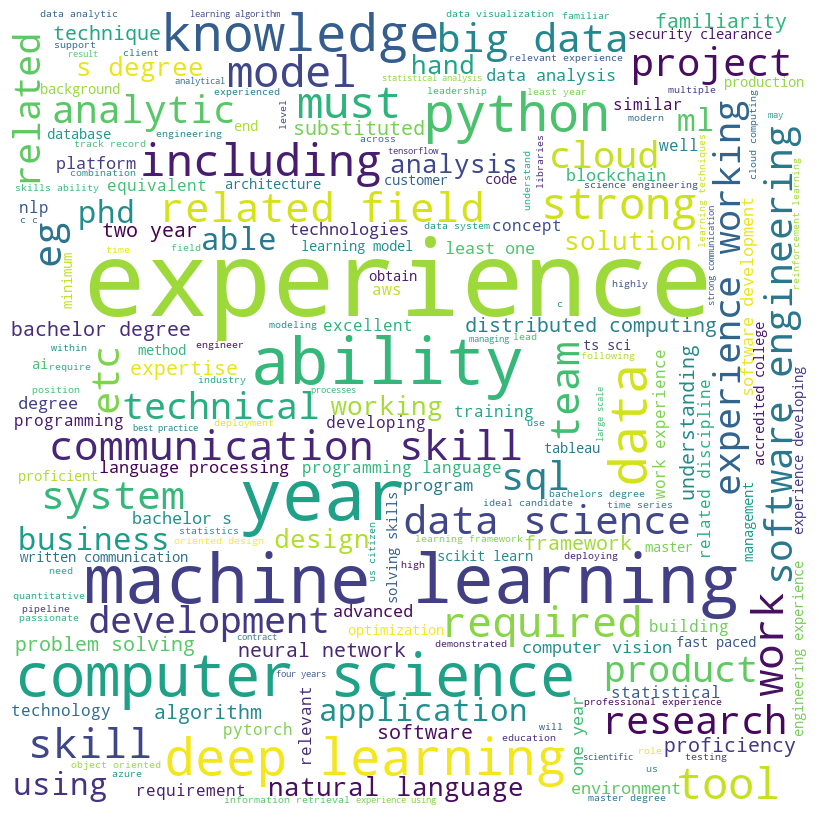

In [25]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd


# concatenate all the text in the column into a single string
df["Qualifications"][df["Qualifications"] != df["Qualifications"]] = ""
text = ' '.join(df['Qualifications'].values.tolist())

# create a set of stopwords to exclude from the word cloud
stopwords = set(STOPWORDS)

# create a WordCloud object with the stopwords set and other parameters
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stopwords, colormap = colors)

# generate the word cloud from the text
wordcloud.generate(text)

# visualize the word cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()